In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import numpy as np

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/Integrated_MPN_scvi_genotyped_nb.h5ad')


In [3]:
variant = 'JAK2 c.1849G>T'

/tmp/ipykernel_1190733/1342087562.py:1: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  adata.obs['genotype'] = adata.obsm['genotypes'][[variant + '_wt', variant + '_mutated', variant + '_heterozygous']].idxmax(axis=1, skipna=True)


55524 cells with high confidence genotyping for JAK2 c.1849G>T
37


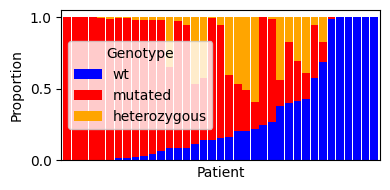

In [4]:
adata.obs['genotype'] = adata.obsm['genotypes'][[variant + '_wt', variant + '_mutated', variant + '_heterozygous']].idxmax(axis=1, skipna=True)
adata.obs['genotype'] = adata.obs['genotype'].str.replace(variant + '_', '', regex=False)

condition = (adata.obsm['genotypes'][variant + '_high_confidence_counts'] > 1)
print(len(adata[condition].obs), 'cells with high confidence genotyping for', variant)

# Get all patient IDs
patients = adata.obs['patient'].unique()

# Prepare a DataFrame to hold genotype proportions for each patient
genotype_counts = pd.DataFrame(index=['wt', 'heterozygous', 'mutated'], columns=patients)

for patient in patients:
    counts = adata[condition & (adata.obs['patient'] == patient)].obs['genotype'].value_counts(normalize=True)
    for genotype in ['wt', 'heterozygous', 'mutated']:
        genotype_counts.loc[genotype, patient] = counts.get(genotype, 0)

genotype_counts = genotype_counts.astype(float)
genotype_counts = genotype_counts.transpose()

ax = genotype_counts.sort_values('wt')[['wt', 'mutated', 'heterozygous']].plot(
    kind='bar',
    stacked=True,
    color=['blue', 'red', 'orange'],
    figsize=(4,2),
    width=0.9  # make bars narrower and closer
)
ax.set_xticklabels([])  # remove x tick labels
ax.set_xticks([])  # remove x ticks
ax.set_yticks([0, 0.5, 1])
plt.ylabel('Proportion')
plt.xlabel('Patient')
plt.legend(title='Genotype')
plt.tight_layout()

print(len(patients))

plt.savefig('../plots/JAK2_mutated_proportions.pdf', bbox_inches='tight')


In [5]:
genotype_counts['cell_count_2_UMI'] = genotype_counts.index.map(adata[condition].obs['sample'].value_counts().to_dict())
condition_1UMI = (adata.obsm['genotypes'][variant + '_high_confidence_counts'] > 0)
genotype_counts['cell_count_1_UMI'] = genotype_counts.index.map(adata[condition_1UMI].obs['sample'].value_counts().to_dict())


In [6]:
### check proportion of cells with 2 UMIs among those with at least 1 UMI
1 - (genotype_counts['cell_count_2_UMI'].astype(int).sum() / genotype_counts['cell_count_1_UMI'].astype(int).sum())

0.7117014206197558

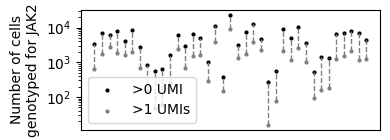

In [7]:
fig, ax = plt.subplots(figsize=(4, 1.5))
sorted_counts = genotype_counts.sort_values('wt')
x = np.arange(len(sorted_counts))
y2 = sorted_counts['cell_count_2_UMI'].astype(float)
y1 = sorted_counts['cell_count_1_UMI'].astype(float)

for xi, low, high in zip(x, y2, y1):
    ax.plot([xi, xi], [low, high], color='gray', linewidth=1, linestyle='--')
ax.scatter(x, y1, color='k', label='>0 UMI', s=4)
ax.scatter(x, y2, color='grey', label='>1 UMIs', s=4)
ax.legend()

ax.set_ylabel('Number of cells\ngenotyped for JAK2')
ax.set_xticks([])  # remove x ticks

ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../plots/JAK2_genotyped_cell_counts.pdf', bbox_inches='tight')